In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.convolution import Gaussian1DKernel, convolve
import requests
from PIL import Image
from io import BytesIO
import os

from matplotlib.patches import Circle
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman', 'Palatino', 'Computer Modern Roman']
# os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
# plt.rcParams['text.usetex'] = True
plt.style.use('../data/plots/desi.mplstyle')

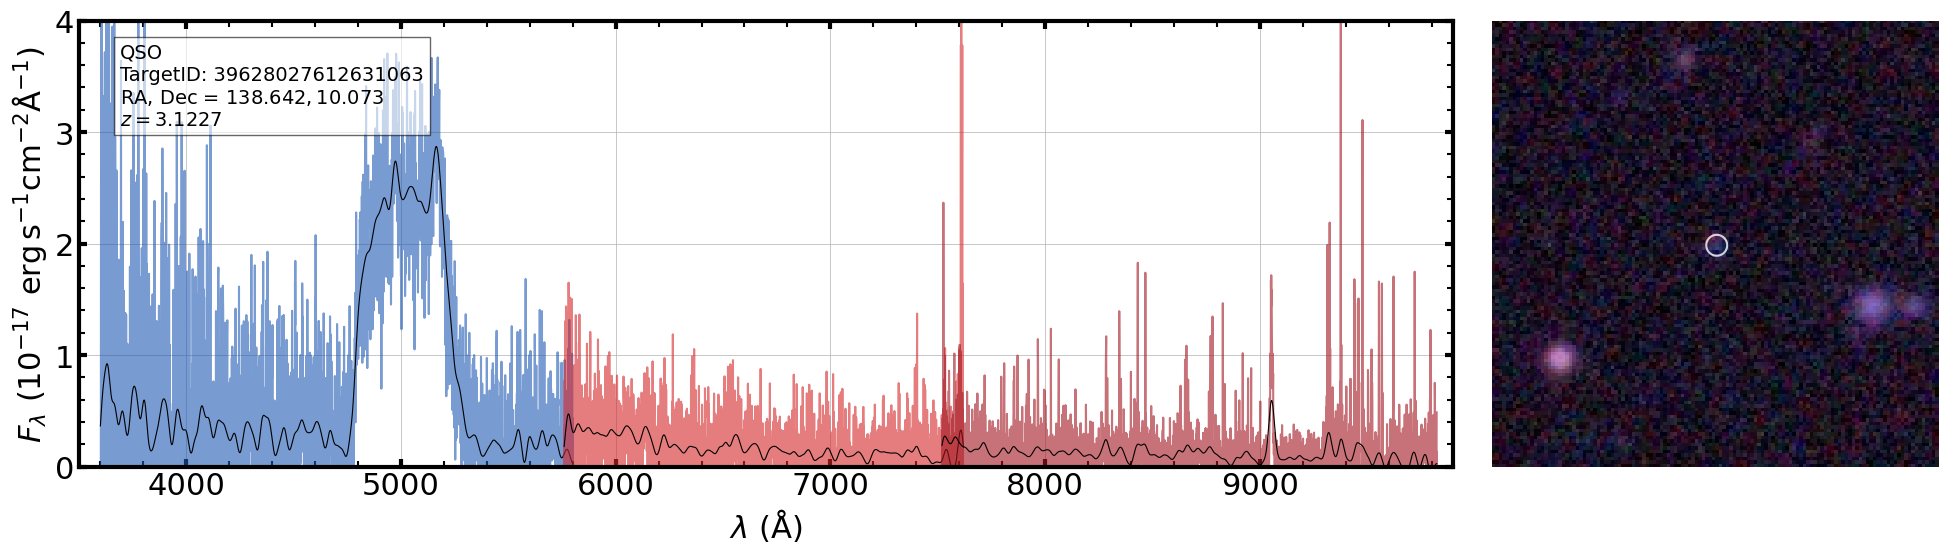

In [7]:
nights = ['20220130']
tiles = ['8643']

for i in range(len(nights)):
    night = nights[i]
    tile  = tiles[i]
    ls = ['']
    for l in ls:
        line = l.split('_')
        tgt_id = 39628027612631063
        petal = 7
        night = os.listdir(f'/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/{tile}')[0]
        redrock_file = f'/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/{tile}/{night}/redrock-{petal}-{tile}-thru{night}.fits'
        coadd_file = f'/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/{tile}/{night}/coadd-{petal}-{tile}-thru{night}.fits'
        kernel  = Gaussian1DKernel(15)
        kernel2 = Gaussian1DKernel(0.5)

        with fits.open(redrock_file) as rr:
            zb = rr[1].data
            sel = zb['TARGETID'] == tgt_id
            if not np.any(sel):
                raise ValueError(f"TargetID {tgt_id} no encontrado en {redrock_file}")
            zfit  = zb['Z'][sel][0]
            zerr  = zb['ZERR'][sel][0]
            zwarn = zb['ZWARN'][sel][0]
            z_type = zb['SPECTYPE'][sel][0]

        with fits.open(coadd_file) as co:
            fibermap= co['FIBERMAP'].data

            selfm   = fibermap['TARGETID'] == tgt_id
            if not np.any(selfm):
                raise ValueError(f"TargetID {tgt_id} no encontrado en fibermap de {coadd_file}")
            idx     = np.where(selfm)[0][0]

            wave_b = co[3].data
            wave_r = co[8].data
            wave_z = co[13].data

            flux_b   = co[4].data[idx]
            flux_r   = co[9].data[idx]
            flux_z   = co[14].data[idx]

            ivar_b   = co[5].data[idx]
            ivar_r   = co[10].data[idx]
            ivar_z   = co[15].data[idx]

        smooth_b = convolve(flux_b, kernel)
        smooth_r = convolve(flux_r, kernel)
        smooth_z = convolve(flux_z, kernel)
        
        flux_b = convolve(flux_b,kernel2)
        flux_r = convolve(flux_r,kernel2)
        flux_z = convolve(flux_z,kernel2)

        flux_all   = np.hstack([flux_b, flux_r, flux_z])
        smooth_all = np.hstack([smooth_b, smooth_r, smooth_z])
        ivar_all   = np.hstack([ivar_b, ivar_r, ivar_z])
        err_all    = 1/np.sqrt(np.where(ivar_all>0, ivar_all, np.nan))

        ra   = fibermap['TARGET_RA'][idx]
        dec  = fibermap['TARGET_DEC'][idx]

        err_b =  1/np.sqrt(np.where(ivar_b>0, ivar_b, np.nan))
        err_r =  1/np.sqrt(np.where(ivar_r>0, ivar_r, np.nan))
        err_z =  1/np.sqrt(np.where(ivar_z>0, ivar_z, np.nan))

        fig, (ax, ax_im) = plt.subplots(
            1, 2, figsize=(20,6),
            gridspec_kw={'width_ratios':[3,1]}
        )

        for flux, wave, smooth, err, color, label in zip(
            (flux_b,   flux_r,   flux_z),
            (wave_b,   wave_r,   wave_z),
            (smooth_b, smooth_r, smooth_z),
            (err_b,    err_r,    err_z),
            ('#1f58b4','#d52628','#a1151f'),
            ('B','R','Z')
        ):
            ax.plot(wave, flux,   color=color, alpha=0.6)#, label=f'{label} orig')
            # ax.fill_between(wave,
            #                 flux,#-err,
            #                 flux,#+err,
            #                 color=color,
            #                 alpha=0.2)
            ax.plot(wave, smooth, color='k', linewidth=0.8)

        ax.set_xlim(3500, 9900)
        ax.set_xlabel(r'$\lambda\ (\mathrm{\AA})$')
        ax.set_ylabel(r'$F_{\lambda}\ (10^{-17}\ \mathrm{erg\,s^{-1}cm^{-2}\AA^{-1}})$')
        ax.grid(linewidth=0.5)

        info = (
            f"{z_type}\n"
            f"TargetID: {tgt_id}\n"
            f"RA, Dec = ${ra:.3f}, {dec:.3f}$\n"
            # f"r-fiber flux: {rfm:.2f}\n"
            f"$z = {zfit:.4f}$"
            # "$\n$ZWARN = {zwarn}$"
        )
        ax.text(0.03, 0.95, info, transform=ax.transAxes,
                va='top', fontsize=14, bbox=dict(facecolor='white', alpha=0.6))

        cutout_url = (
            f"https://www.legacysurvey.org/viewer/cutout.jpg?"
            f"ra={ra}&dec={dec}"
            f"&layer=ls-dr10"
            f"&pixscale=0.262"
            f"&bands=grz"
            f"&size=128"
        )
        img = Image.open(BytesIO(requests.get(cutout_url).content))
        ax_im.imshow(img)
        ax_im.axis('off')

        w, h = img.size
        cx, cy = w/2, h/2
        radius = 3

        circ = Circle(
            (cx, cy), radius,
            edgecolor='white',
            facecolor='none',
            linewidth=1.5,
            alpha=0.8
        )

        ax.set_xlim(3500, 9900)
        ax.set_ylim(0,4)

        ax_im.add_patch(circ)
        ax_im.axis('off')

        plt.tight_layout()
        plt.savefig('plot.png', dpi=360)
        plt.show()

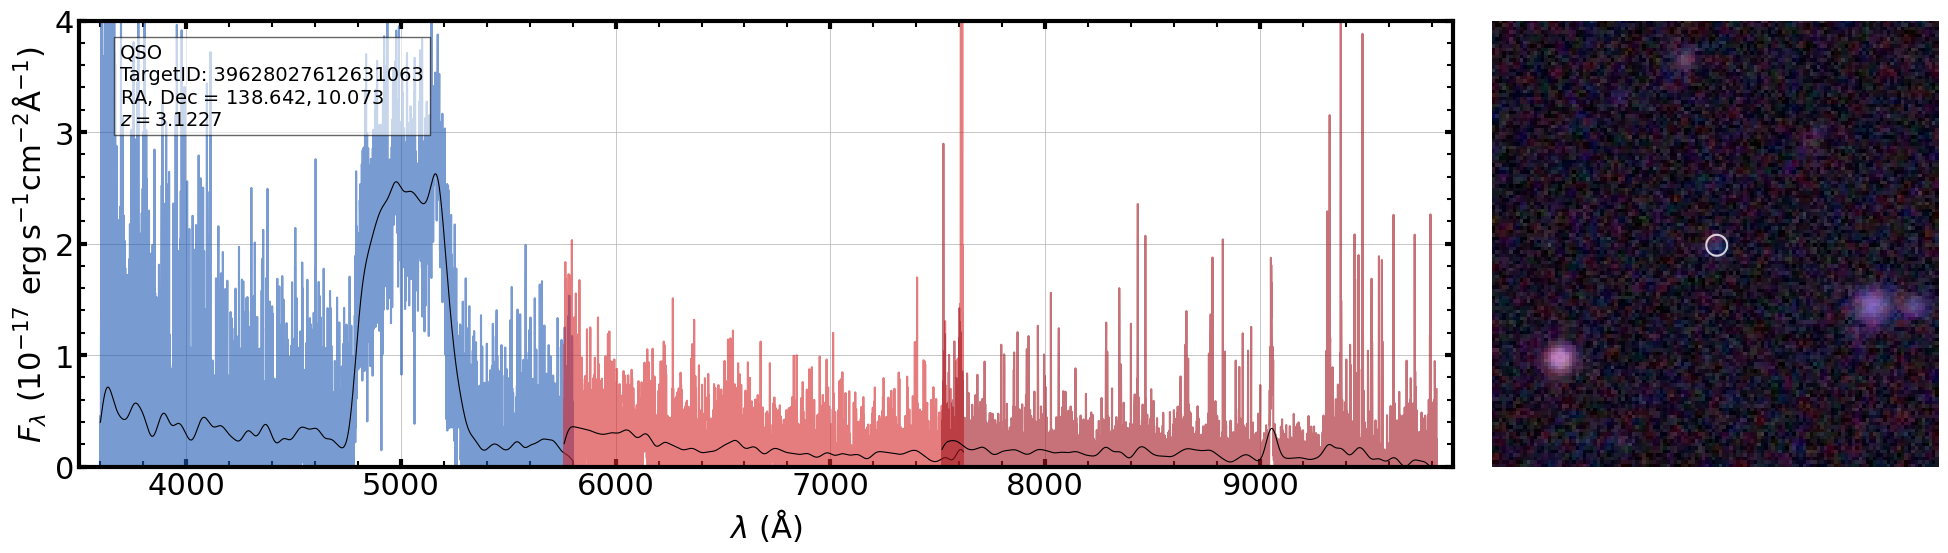

In [9]:
nights = ['20220130']
tiles = ['8643']

for i in range(len(nights)):
    night = nights[i]
    tile  = tiles[i]
    ls = ['']
    for l in ls:
        line = l.split('_')
        tgt_id = 39628027612631063
        petal = 7
        night = os.listdir(f'/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/{tile}')[0]
        redrock_file = f'/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/{tile}/{night}/redrock-{petal}-{tile}-thru{night}.fits'
        coadd_file = f'/global/cfs/cdirs/desi/spectro/redux/jura/tiles/cumulative/{tile}/{night}/coadd-{petal}-{tile}-thru{night}.fits'
        kernel  = Gaussian1DKernel(30)
        kernel2 = Gaussian1DKernel(0.5)

        with fits.open(redrock_file) as rr:
            zb = rr[1].data
            sel = zb['TARGETID'] == tgt_id
            if not np.any(sel):
                raise ValueError(f"TargetID {tgt_id} no encontrado en {redrock_file}")
            zfit  = zb['Z'][sel][0]
            zerr  = zb['ZERR'][sel][0]
            zwarn = zb['ZWARN'][sel][0]
            z_type = zb['SPECTYPE'][sel][0]

        with fits.open(coadd_file) as co:
            fibermap= co['FIBERMAP'].data

            selfm   = fibermap['TARGETID'] == tgt_id
            if not np.any(selfm):
                raise ValueError(f"TargetID {tgt_id} no encontrado en fibermap de {coadd_file}")
            idx     = np.where(selfm)[0][0]

            wave_b = co[3].data
            wave_r = co[8].data
            wave_z = co[13].data

            flux_b   = co[4].data[idx]
            flux_r   = co[9].data[idx]
            flux_z   = co[14].data[idx]

            ivar_b   = co[5].data[idx]
            ivar_r   = co[10].data[idx]
            ivar_z   = co[15].data[idx]

        smooth_b = convolve(flux_b, kernel)
        smooth_r = convolve(flux_r, kernel)
        smooth_z = convolve(flux_z, kernel)
        
        # flux_b = convolve(flux_b,kernel2)
        # flux_r = convolve(flux_r,kernel2)
        # flux_z = convolve(flux_z,kernel2)

        flux_all   = np.hstack([flux_b, flux_r, flux_z])
        smooth_all = np.hstack([smooth_b, smooth_r, smooth_z])
        ivar_all   = np.hstack([ivar_b, ivar_r, ivar_z])
        err_all    = 1/np.sqrt(np.where(ivar_all>0, ivar_all, np.nan))

        ra   = fibermap['TARGET_RA'][idx]
        dec  = fibermap['TARGET_DEC'][idx]

        err_b =  1/np.sqrt(np.where(ivar_b>0, ivar_b, np.nan))
        err_r =  1/np.sqrt(np.where(ivar_r>0, ivar_r, np.nan))
        err_z =  1/np.sqrt(np.where(ivar_z>0, ivar_z, np.nan))

        fig, (ax, ax_im) = plt.subplots(
            1, 2, figsize=(20,6),
            gridspec_kw={'width_ratios':[3,1]}
        )

        for flux, wave, smooth, err, color, label in zip(
            (flux_b,   flux_r,   flux_z),
            (wave_b,   wave_r,   wave_z),
            (smooth_b, smooth_r, smooth_z),
            (err_b,    err_r,    err_z),
            ('#1f58b4','#d52628','#a1151f'),
            ('B','R','Z')
        ):
            ax.plot(wave, flux,   color=color, alpha=0.6)#, label=f'{label} orig')
            # ax.fill_between(wave,
            #                 flux,#-err,
            #                 flux,#+err,
            #                 color=color,
            #                 alpha=0.2)
            ax.plot(wave, smooth, color='k', linewidth=0.8)

        ax.set_xlim(3500, 9900)
        ax.set_xlabel(r'$\lambda\ (\mathrm{\AA})$')
        ax.set_ylabel(r'$F_{\lambda}\ (10^{-17}\ \mathrm{erg\,s^{-1}cm^{-2}\AA^{-1}})$')
        ax.grid(linewidth=0.5)

        info = (
            f"{z_type}\n"
            f"TargetID: {tgt_id}\n"
            f"RA, Dec = ${ra:.3f}, {dec:.3f}$\n"
            # f"r-fiber flux: {rfm:.2f}\n"
            f"$z = {zfit:.4f}$"
            # "$\n$ZWARN = {zwarn}$"
        )
        ax.text(0.03, 0.95, info, transform=ax.transAxes,
                va='top', fontsize=14, bbox=dict(facecolor='white', alpha=0.6))

        cutout_url = (
            f"https://www.legacysurvey.org/viewer/cutout.jpg?"
            f"ra={ra}&dec={dec}"
            f"&layer=ls-dr10"
            f"&pixscale=0.262"
            f"&bands=grz"
            f"&size=128"
        )
        img = Image.open(BytesIO(requests.get(cutout_url).content))
        ax_im.imshow(img)
        ax_im.axis('off')

        w, h = img.size
        cx, cy = w/2, h/2
        radius = 3

        circ = Circle(
            (cx, cy), radius,
            edgecolor='white',
            facecolor='none',
            linewidth=1.5,
            alpha=0.8
        )

        ax.set_xlim(3500, 9900)
        ax.set_ylim(0,4)

        ax_im.add_patch(circ)
        ax_im.axis('off')

        plt.tight_layout()
        plt.savefig('plot.png', dpi=360)
        plt.show()

In [10]:
import numpy as np

np.savez(
    f"spectrum_tile{tile}_tgt{tgt_id}.npz",
    wave_b=wave_b, flux_b=flux_b, smooth_b=smooth_b, err_b=err_b,
    wave_r=wave_r, flux_r=flux_r, smooth_r=smooth_r, err_r=err_r,
    wave_z=wave_z, flux_z=flux_z, smooth_z=smooth_z, err_z=err_z,
    ra=ra, dec=dec, zfit=zfit
)

import requests
cutout_data = requests.get(cutout_url).content
with open(f"cutout_tile{tile}_tgt{tgt_id}.jpg", "wb") as f:
    f.write(cutout_data)
